# 01 — Data Audit of SentiPers

This notebook performs an initial audit of the SentiPers dataset structure and quality.

**This notebook covers:**

- Dataset dimensions
- Column types and meanings
- Missing and blank values
- Distribution of the five sentiment classes
- Duplicate texts
- Texts with conflicting labels
- Duplicates after initial normalization
- Text length characteristics
- Number of source files


## Data Audit list

- STEP 01 Imports and Paths
- STEP 02 Load Raw Dataset
- STEP 02.1 Validate Dataset Structure
- STEP 03 Preview Raw Data
- STEP 04 Inspect Dataset Structure
- STEP 05 Check Missing and Blank Values
- STEP 06 Sentiment Class Distribution
- STEP 07 Source File Distribution
- STEP 08 Exact Duplicate Texts
- STEP 09 Conflicting Labels
- STEP 10 Initial Text Normalization
- STEP 11 Normalized Duplicate Texts
- STEP 12 Text Length Analysis
- STEP 13 Short and Long Texts
- STEP 14 Audit Summary
- STEP 15 Save Audit Reports
- STEP 16 Final Raw Data Check
- Data Audit Conclusion


## STEP 01 — Import Required Libraries

Preparing the required tools for the project


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display


from pathlib import Path

PLOTS_DIR = Path("../outputs/plots/01_data_audit")

PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 150)

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


## STEP 02 — Load Dataset

Reading the original file and storing the data in a DataFrame


In [4]:
# %pip install openpyxl
DATA_PATH = Path("../data/raw/sentipers.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The sentipers.xlsx file was not found."
    )

df_raw = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset path: {DATA_PATH.resolve()}")

Dataset loaded successfully.
Dataset path: D:\Bachelor Project\PersianSentimentProject_Submission\data\raw\sentipers.xlsx


## STEP 02.1 — Dataset Structure Validation

Checking required columns and validating sentiment labels


In [5]:
EXPECTED_COLUMNS = [
    "index",
    "sid",
    "text",
    "polarity",
    "file",
]

EXPECTED_LABELS = {
    -2,
    -1,
    0,
    1,
    2,
}


def dataframe_fingerprint(frame):
    comparable_frame = (
        frame
        .astype("string")
        .fillna("<NA>")
    )

    return int(
        pd.util.hash_pandas_object(
            comparable_frame,
            index=True,
        ).sum()
    )


missing_columns = [
    column
    for column in EXPECTED_COLUMNS
    if column not in df_raw.columns
]

unexpected_columns = [
    column
    for column in df_raw.columns
    if column not in EXPECTED_COLUMNS
]

observed_labels = set(
    df_raw["polarity"]
    .dropna()
    .unique()
)

invalid_labels = (
    observed_labels
    - EXPECTED_LABELS
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

if unexpected_columns:
    print(
        f"Unexpected columns: {unexpected_columns}"
    )

if invalid_labels:
    raise ValueError(
        f"Invalid sentiment labels: {sorted(invalid_labels)}"
    )

RAW_ROW_COUNT = len(df_raw)
RAW_COLUMN_COUNT = df_raw.shape[1]
RAW_FINGERPRINT = dataframe_fingerprint(df_raw)

print("Dataset structure is valid.")
print(f"Observed labels: {sorted(observed_labels)}")
print(f"Initial rows: {RAW_ROW_COUNT:,}")
print(f"Initial columns: {RAW_COLUMN_COUNT}")

[]

Dataset structure is valid.
Observed labels: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Initial rows: 15,683
Initial columns: 5


## STEP 03 — Preview Initial Samples

Viewing initial rows to inspect the general dataset structure


In [41]:
display(df_raw.head())

,index,sid,text,polarity,file
0,0,rev-1,اینک قصد داریم پرینتر دیگری از پرینترهای لیزری کمپانی Hp را معرفی کنیم.,0,data/main/HP LaserJet M1132.xml
1,1,rev-2,پرینتری چند کاره از رده‌ی Entry Level یا سطح مبتدی.,0,data/main/HP LaserJet M1132.xml
2,2,rev-3,به هر صورت اکنون ما در دنیایی زندگی می‌کنیم، که کاربران پرینترها انتظارات بالاتری علاوه بر گرفتن پرینت ساده از دستگاه خود دارند.,0,data/main/HP LaserJet M1132.xml
3,3,rev-4,به صورتی که توانایی کپی کردن، اسکن، فکس، پرینت عکس، پرینت دورو، قابلیت اتصال از طریق Bluetooth و WiFi را نیز باید داشته باشد.,0,data/main/HP LaserJet M1132.xml
4,4,rev-5,به هر صورت معمولا چیزی که بیشتر کاربران از پرینتری پر کار در این سطح قیمت برای خانه و یا دفتر کار انتظار دارند، تولید پرینت های با کیفیت بالا، ب...,2,data/main/HP LaserJet M1132.xml


## STEP 04 — Dataset Structure Analysis

Analyzing dimensions, data types, and unique column values


In [43]:
structure_summary = pd.DataFrame(
    {
        "column": df_raw.columns,
        "dtype": [
            str(df_raw[column].dtype)
            for column in df_raw.columns
        ],
        "non_null_count": [
            df_raw[column].notna().sum()
            for column in df_raw.columns
        ],
        "unique_count": [
            df_raw[column].nunique(dropna=True)
            for column in df_raw.columns
        ],
    }
)

print(f"Number of rows: {df_raw.shape[0]:,}")
print(f"Number of columns: {df_raw.shape[1]}")

display(structure_summary)

Number of rows: 15,683
Number of columns: 5


,column,dtype,non_null_count,unique_count
0,index,int64,15683,8809
1,sid,object,15683,1250
2,text,object,15683,13525
3,polarity,int64,15683,5
4,file,object,15683,290


## STEP 05 — Missing and Blank Values Analysis

Calculating missing values and empty strings in each column


In [45]:
missing_counts = df_raw.isna().sum()

blank_counts = pd.Series(
    {
        column: (
            df_raw[column]
            .astype("string")
            .str.strip()
            .eq("")
            .sum()
        )
        for column in df_raw.columns
    }
)

missing_summary = pd.DataFrame(
    {
        "column": df_raw.columns,
        "missing_count": missing_counts.values,
        "blank_count": blank_counts.values,
    }
)

missing_summary["total_missing_or_blank"] = (
    missing_summary["missing_count"]
    + missing_summary["blank_count"]
)

missing_summary["percentage"] = (
    missing_summary["total_missing_or_blank"]
    / len(df_raw)
    * 100
).round(4)

missing_values_total = int(
    missing_summary["missing_count"].sum()
)

blank_values_total = int(
    missing_summary["blank_count"].sum()
)

display(missing_summary)

,column,missing_count,blank_count,total_missing_or_blank,percentage
0,index,0,0,0,0.0
1,sid,0,0,0,0.0
2,text,0,0,0,0.0
3,polarity,0,0,0,0.0
4,file,0,0,0,0.0


## STEP 06 — Sentiment Class Distribution

Calculating the number and percentage of samples in five sentiment classes


,polarity,count,class_name,percentage
0,-2,212,Very Negative,1.35
1,-1,1574,Negative,10.04
2,0,5938,Neutral,37.86
3,1,5019,Positive,32.00
4,2,2940,Very Positive,18.75


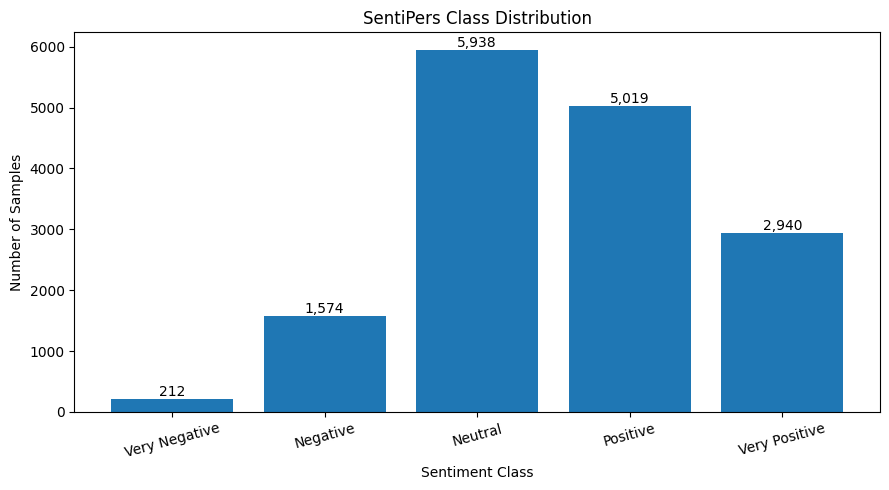

In [12]:
label_order = [-2, -1, 0, 1, 2]

label_names = {
    -2: "Very Negative",
    -1: "Negative",
    0: "Neutral",
    1: "Positive",
    2: "Very Positive",
}

class_distribution = (
    df_raw["polarity"]
    .value_counts()
    .reindex(label_order, fill_value=0)
    .rename_axis("polarity")
    .reset_index(name="count")
)

class_distribution["class_name"] = class_distribution["polarity"].map(label_names)

class_distribution["percentage"] = (
    class_distribution["count"] / len(df_raw) * 100
).round(2)

observed_class_count = int(df_raw["polarity"].nunique())

display(class_distribution)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    class_distribution["class_name"],
    class_distribution["count"],
)

ax.set_title("SentiPers Class Distribution")
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Number of Samples")

for bar, count in zip(
    bars,
    class_distribution["count"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    PLOTS_DIR / "class_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## STEP 07 — Source File Analysis

Analyzing the number of source files and extracted sentences from each file


In [49]:
source_summary = (
    df_raw["file"]
    .value_counts(dropna=False)
    .rename_axis("file")
    .reset_index(name="sentence_count")
)

source_file_count = int(
    df_raw["file"].nunique(dropna=True)
)

print(f"Number of source files: {source_file_count:,}")

display(source_summary.head(20))

Number of source files: 290


,file,sentence_count
0,data/main/Apple iPhone 5 - 16GB.xml,607
1,data/main/Microsoft Xbox 360 Elite.xml,368
2,data/extra/HTC Butterfly.xml,338
3,data/extra/Samsung Galaxy Note 10.1 N8000 - 16GB.xml,310
4,data/main/Sony Ericsson Xperia Ray.xml,297
5,data/extra/Sony Ericsson Xperia Mini.xml,284
6,data/extra/LG Optimus L7 II Dual P715.xml,273
7,data/extra/Apple iPhone 5 - 64GB.xml,265
8,data/extra/Sony Ericsson Live With Walkman.xml,240
9,data/main/Asus Transformer Pad Infinity TF700T 64GB + Dock.xml,229


## STEP 08 — Exact Duplicate Text Analysis

Identifying texts that appear more than once without any difference in the dataset.


In [8]:
exact_duplicate_mask = df_raw.duplicated(
    subset=["text"],
    keep=False,
)

exact_duplicate_rows = (
    df_raw.loc[exact_duplicate_mask]
    .sort_values(["text", "polarity"])
    .reset_index(drop=True)
)

exact_unique_text_count = int(
    df_raw["text"].nunique(dropna=False)
)

exact_duplicate_group_count = int(
    exact_duplicate_rows["text"].nunique()
)

exact_extra_duplicate_rows = int(
    df_raw.duplicated(
        subset=["text"],
        keep="first",
    ).sum()
)

print(
    f"Unique exact texts: "
    f"{exact_unique_text_count:,}"
)

print(
    f"Exact duplicate groups: "
    f"{exact_duplicate_group_count:,}"
)

print(
    f"Extra duplicate rows: "
    f"{exact_extra_duplicate_rows:,}"
)

display(exact_duplicate_rows.head(20))

Unique exact texts: 13,525
Exact duplicate groups: 2,158
Extra duplicate rows: 2,158


,index,sid,text,polarity,file
0,1,gr-1-2,(به دليل مشکل قطع شدن WIFI بعد از قرار دادن سيم کارت.,-1,data/main/Asus Google Nexus 7 3G - 32GB.xml
1,10370,-,(به دليل مشکل قطع شدن WIFI بعد از قرار دادن سيم کارت.,-1,data/extra/Asus Google Nexus 7 3G - 32GB.xml
2,11380,-,) جاي قرار گرفتن فلاشه که اولين عکسي که ميخواي بگيري فلاش باز ميشه و مياد بالا که بايد حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,-1,data/extra/Sony Cyber-Shot DSC-HX10V.xml
3,4,gr-1-5,) جاي قرار گرفتن فلاشه که اولين عکسي که ميخواي بگيري فلاش باز ميشه و مياد بالا که بايد حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,0,data/main/Sony Cyber-Shot DSC-HX10V.xml
4,44,rev-45,) خریداران خود را در اکثر زمینه‌ها راضی نگاه خواهد داشت.,0,data/main/IBM Lenovo Essential G580-J.xml
5,9631,-,) خریداران خود را در اکثر زمینه‌ها راضی نگاه خواهد داشت.,0,data/extra/IBM Lenovo Essential G580-J_Hosseini.xml
6,3,gr-3-4,) مشکل غير فعال شدن واي فاي در زمان ورود سيمکارت خيلي اذيت مي کنه چون بايد دوباره به تنظيمات کارخانه برگشت.,-2,data/main/Asus Google Nexus 7 3G - 32GB.xml
7,10376,-,) مشکل غير فعال شدن واي فاي در زمان ورود سيمکارت خيلي اذيت مي کنه چون بايد دوباره به تنظيمات کارخانه برگشت.,-2,data/extra/Asus Google Nexus 7 3G - 32GB.xml
8,6,cr-2-7,).,0,data/main/HP LaserJet P1102.xml
9,942,-,).,0,data/extra/Asus PadFone 2 -32GB.xml


## STEP 09 — Conflicting Label Analysis

Identifying identical texts that are assigned to more than one sentiment label.


In [53]:
label_count_per_text = (
    df_raw
    .groupby("text")["polarity"]
    .nunique()
)

conflicting_texts = (
    label_count_per_text[
        label_count_per_text > 1
    ]
    .index
)

conflicting_rows = (
    df_raw[
        df_raw["text"].isin(conflicting_texts)
    ]
    .sort_values(
        ["text", "polarity", "file"]
    )
    .reset_index(drop=True)
)

conflicting_group_count = int(
    len(conflicting_texts)
)

print(
    f"Conflicting text groups: "
    f"{conflicting_group_count:,}"
)

print(
    f"Rows in conflicting groups: "
    f"{len(conflicting_rows):,}"
)

display(conflicting_rows.head(30))

Conflicting text groups: 122
Rows in conflicting groups: 244


,index,sid,text,polarity,file
0,11380,-,) جاي قرار گرفتن فلاشه که اولين عکسي که ميخواي بگيري فلاش باز ميشه و مياد بالا که بايد حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,-1,data/extra/Sony Cyber-Shot DSC-HX10V.xml
1,4,gr-1-5,) جاي قرار گرفتن فلاشه که اولين عکسي که ميخواي بگيري فلاش باز ميشه و مياد بالا که بايد حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,0,data/main/Sony Cyber-Shot DSC-HX10V.xml
2,11548,-,N43SM در کانفیگ‌هایی با ظرفیت‌ها‌ی هارد دیسک مختلف نیز ساخته شده است و از حافظه‌ها‌ی SSD نیز پشتیبانی می‌کند.,0,data/extra/Asus N43SM-C_Hosseini.xml
3,21,rev-22,N43SM در کانفیگ‌هایی با ظرفیت‌ها‌ی هارد دیسک مختلف نیز ساخته شده است و از حافظه‌ها‌ی SSD نیز پشتیبانی می‌کند.,1,data/main/Asus N43SM-C.xml
4,0,gr-5-1,آينده از آن سامسونگه!,0,data/main/Samsung LED 55ES8880.xml
5,8968,-,آينده از آن سامسونگه!,2,data/extra/Samsung LED 55ES8880.xml
6,0,gr-21-1,احتمالا سامسونگ علاقه زيادي داره که زير مجموعه اپل بشه اين از پشت و بقل دقيقا ميشه همون آي پد واقعا بايد به طراح اين دستگاه جايزه نوبل داد!,0,data/main/Samsung Galaxy Tab 2 10.1 P5100 - 16GB.xml
7,11335,-,احتمالا سامسونگ علاقه زيادي داره که زير مجموعه اپل بشه اين از پشت و بقل دقيقا ميشه همون آي پد واقعا بايد به طراح اين دستگاه جايزه نوبل داد!,1,data/extra/Samsung Galaxy Tab 2 10.1 P5100 - 16GB.xml
8,4,gr-11-5,احتمالا من اولين مشتريش باشم، چون خريد از بازار علاوه بر وجود قيمت هاي غير واقعي احتمال دستکاري تو جعبه رو داره.,-1,data/main/HTC One X Plus - 64GB.xml
9,3711,-,احتمالا من اولين مشتريش باشم، چون خريد از بازار علاوه بر وجود قيمت هاي غير واقعي احتمال دستکاري تو جعبه رو داره.,1,data/extra/HTC One X Plus - 64GB.xml


## STEP 10 — Initial Text Normalization

Creating a normalized version only for detecting hidden duplicates.


In [9]:
import re
import unicodedata


character_translation = str.maketrans(
    {
        "\u064A": "\u06CC",
        "\u0649": "\u06CC",
        "\u0643": "\u06A9",
        "\u0629": "\u0647",
        "\u06C0": "\u0647",
    }
)


def normalize_text_for_audit(value):
    if pd.isna(value):
        return ""

    text = str(value)

    text = unicodedata.normalize(
        "NFKC",
        text,
    )

    text = text.translate(
        character_translation
    )

    text = re.sub(
        r"[\u200e\u200f\ufeff]",
        "",
        text,
    )

    text = text.replace(
        "\u200c",
        " ",
    )

    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    return text


audit_df = df_raw.copy()

audit_df["normalized_text"] = (
    audit_df["text"]
    .apply(normalize_text_for_audit)
)

normalization_examples = (
    audit_df.loc[
        audit_df["text"].astype("string")
        != audit_df["normalized_text"],
        ["text", "normalized_text"],
    ]
    .head(10)
)

display(normalization_examples)

,text,normalized_text
1,پرینتری چند کاره از رده‌ی Entry Level یا سطح مبتدی.,پرینتری چند کاره از رده ی Entry Level یا سطح مبتدی.
2,به هر صورت اکنون ما در دنیایی زندگی می‌کنیم، که کاربران پرینترها انتظارات بالاتری علاوه بر گرفتن پرینت ساده از دستگاه خود دارند.,به هر صورت اکنون ما در دنیایی زندگی می کنیم، که کاربران پرینترها انتظارات بالاتری علاوه بر گرفتن پرینت ساده از دستگاه خود دارند.
3,به صورتی که توانایی کپی کردن، اسکن، فکس، پرینت عکس، پرینت دورو، قابلیت اتصال از طریق Bluetooth و WiFi را نیز باید داشته باشد.,به صورتی که توانایی کپی کردن، اسکن، فکس، پرینت عکس، پرینت دورو، قابلیت اتصال از طریق Bluetooth و WiFi را نیز باید داشته باشد.
4,به هر صورت معمولا چیزی که بیشتر کاربران از پرینتری پر کار در این سطح قیمت برای خانه و یا دفتر کار انتظار دارند، تولید پرینت های با کیفیت بالا، ب...,به هر صورت معمولا چیزی که بیشتر کاربران از پرینتری پر کار در این سطح قیمت برای خانه و یا دفتر کار انتظار دارند، تولید پرینت های با کیفیت بالا، با ...
6,M1132 نیز پرینتری است که به نظر یکی از بهترین‌ها برای ایفای این نقش می‌باشد.,M1132 نیز پرینتری است که به نظر یکی از بهترین ها برای ایفای این نقش می باشد.
7,همانطور که گفتیم، M1132 پرینتری لیزری، تک رنگ و چند کاره است.,همانطور که گفتیم، M1132 پرینتری لیزری، تک رنگ و چند کاره است.
8,ابعاد آن 415 x 265 x 250 میلی متر می‌باشد و وزن آن نیز به حدود 7 کیلوگرم می‌رسد که وزنی نسبتا کم محسوب می‌گردد.,ابعاد آن 415 x 265 x 250 میلی متر می باشد و وزن آن نیز به حدود 7 کیلوگرم می رسد که وزنی نسبتا کم محسوب می گردد.
9,این پرینتر بدنه‌ی مشکی استایلیش و البته نه خیلی لوکس دارد و سعی شده که کنترل‌ها و اتصالات کمی هم داشته باشد.,این پرینتر بدنه ی مشکی استایلیش و البته نه خیلی لوکس دارد و سعی شده که کنترل ها و اتصالات کمی هم داشته باشد.
10,سینی جلویی توانایی نگهداری 150 برگ کاغذ A4 را دارد و درست در بالای آن، سینی خروجی قرار گرفته است که به صورت همزمان 100 کاغذ می‌توانند درون آن جای...,سینی جلویی توانایی نگهداری 150 برگ کاغذ A4 را دارد و درست در بالای آن، سینی خروجی قرار گرفته است که به صورت همزمان 100 کاغذ می توانند درون آن جای ...
13,علاوه بر این ها، اتصالات WiFi و Ethernet هم وجود ندارد.,علاوه بر این ها، اتصالات WiFi و Ethernet هم وجود ندارد.


## STEP 11 — Normalized Duplicate Text Analysis

Identifying texts that become identical after character and spacing normalization.


In [57]:
normalized_duplicate_mask = (
    audit_df.duplicated(
        subset=["normalized_text"],
        keep=False,
    )
)

normalized_duplicate_rows = (
    audit_df.loc[
        normalized_duplicate_mask,
        [
            "text",
            "normalized_text",
            "polarity",
            "file",
        ],
    ]
    .sort_values(
        ["normalized_text", "polarity"]
    )
    .reset_index(drop=True)
)

normalized_unique_text_count = int(
    audit_df["normalized_text"]
    .nunique(dropna=False)
)

normalized_duplicate_group_count = int(
    normalized_duplicate_rows[
        "normalized_text"
    ].nunique()
)

normalized_extra_duplicate_rows = int(
    audit_df.duplicated(
        subset=["normalized_text"],
        keep="first",
    ).sum()
)

normalized_label_counts = (
    audit_df
    .groupby("normalized_text")[
        "polarity"
    ]
    .nunique()
)

normalized_conflicting_texts = (
    normalized_label_counts[
        normalized_label_counts > 1
    ]
    .index
)

normalized_conflicting_rows = (
    audit_df[
        audit_df["normalized_text"].isin(
            normalized_conflicting_texts
        )
    ]
    .sort_values(
        [
            "normalized_text",
            "polarity",
            "file",
        ]
    )
    .reset_index(drop=True)
)

normalized_conflicting_group_count = int(
    len(normalized_conflicting_texts)
)

print(
    f"Unique normalized texts: "
    f"{normalized_unique_text_count:,}"
)

print(
    f"Normalized duplicate groups: "
    f"{normalized_duplicate_group_count:,}"
)

print(
    f"Extra normalized duplicate rows: "
    f"{normalized_extra_duplicate_rows:,}"
)

print(
    f"Normalized conflicting groups: "
    f"{normalized_conflicting_group_count:,}"
)

display(normalized_duplicate_rows.head(20))

Unique normalized texts: 13,262
Normalized duplicate groups: 2,291
Extra normalized duplicate rows: 2,421
Normalized conflicting groups: 198


,text,normalized_text,polarity,file
0,"""سپاس""\n","""سپاس""",0,data/main/Apple iPhone 5 - 16GB.xml
1,"""سپاس""","""سپاس""",0,data/main/Apple iPhone 5 - 16GB.xml
2,(به دليل مشکل قطع شدن WIFI بعد از قرار دادن سيم کارت.,(به دلیل مشکل قطع شدن WIFI بعد از قرار دادن سیم کارت.,-1,data/main/Asus Google Nexus 7 3G - 32GB.xml
3,(به دليل مشکل قطع شدن WIFI بعد از قرار دادن سيم کارت.,(به دلیل مشکل قطع شدن WIFI بعد از قرار دادن سیم کارت.,-1,data/extra/Asus Google Nexus 7 3G - 32GB.xml
4,) جاي قرار گرفتن فلاشه که اولين عکسي که ميخواي بگيري فلاش باز ميشه و مياد بالا که بايد حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,) جای قرار گرفتن فلاشه که اولین عکسی که میخوای بگیری فلاش باز میشه و میاد بالا که باید حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,-1,data/extra/Sony Cyber-Shot DSC-HX10V.xml
5,) جاي قرار گرفتن فلاشه که اولين عکسي که ميخواي بگيري فلاش باز ميشه و مياد بالا که بايد حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,) جای قرار گرفتن فلاشه که اولین عکسی که میخوای بگیری فلاش باز میشه و میاد بالا که باید حواست باشه به انگشت اشاره دست چپت برخورد نکنه.,0,data/main/Sony Cyber-Shot DSC-HX10V.xml
6,) خریداران خود را در اکثر زمینه‌ها راضی نگاه خواهد داشت.,) خریداران خود را در اکثر زمینه ها راضی نگاه خواهد داشت.,0,data/main/IBM Lenovo Essential G580-J.xml
7,) خریداران خود را در اکثر زمینه‌ها راضی نگاه خواهد داشت.,) خریداران خود را در اکثر زمینه ها راضی نگاه خواهد داشت.,0,data/extra/IBM Lenovo Essential G580-J_Hosseini.xml
8,) مشکل غير فعال شدن واي فاي در زمان ورود سيمکارت خيلي اذيت مي کنه چون بايد دوباره به تنظيمات کارخانه برگشت.,) مشکل غیر فعال شدن وای فای در زمان ورود سیمکارت خیلی اذیت می کنه چون باید دوباره به تنظیمات کارخانه برگشت.,-2,data/main/Asus Google Nexus 7 3G - 32GB.xml
9,) مشکل غير فعال شدن واي فاي در زمان ورود سيمکارت خيلي اذيت مي کنه چون بايد دوباره به تنظيمات کارخانه برگشت.,) مشکل غیر فعال شدن وای فای در زمان ورود سیمکارت خیلی اذیت می کنه چون باید دوباره به تنظیمات کارخانه برگشت.,-2,data/extra/Asus Google Nexus 7 3G - 32GB.xml


## STEP 12 — Text Length Analysis

Analyzing sentence length based on character count and word count.


,count,mean,std,min,25%,50%,75%,95%,99%,max
char_count,15683.0,104.258560,87.755695,2.0,53.0,87.0,132.0,237.0,410.18,1655.0
word_count,15683.0,21.298412,18.095531,1.0,11.0,18.0,27.0,48.0,86.00,338.0


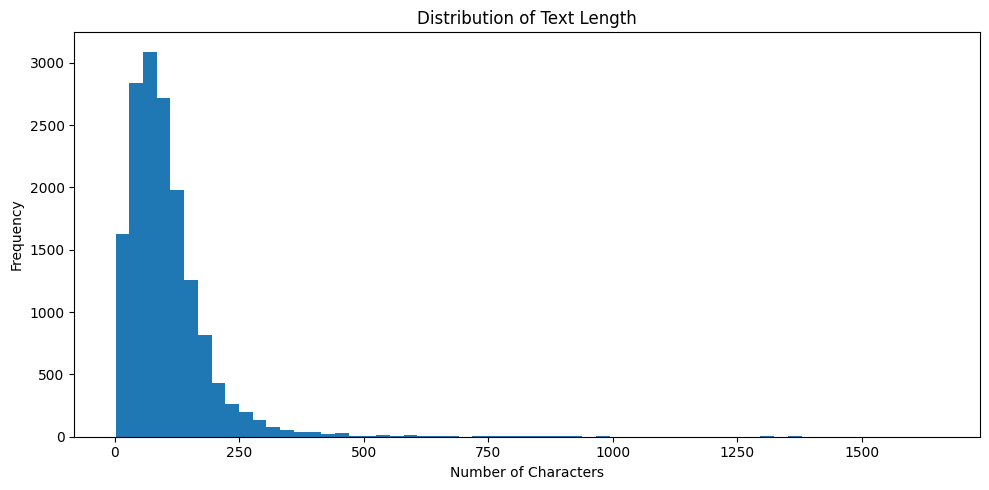

In [11]:
audit_df["char_count"] = (
    audit_df["text"]
    .fillna("")
    .astype(str)
    .str.len()
)

audit_df["word_count"] = (
    audit_df["text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

length_summary = (
    audit_df[
        ["char_count", "word_count"]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .transpose()
)

display(length_summary)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    audit_df["char_count"],
    bins=60,
)

ax.set_title(
    "Distribution of Text Length"
)

ax.set_xlabel(
    "Number of Characters"
)

ax.set_ylabel(
    "Frequency"
)

plt.savefig(
    PLOTS_DIR / "text_length_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.tight_layout()
plt.show()


## STEP 13 — Short and Long Text Analysis

Displaying the shortest and longest sentences in the dataset for quality inspection.


In [61]:
shortest_texts = (
    audit_df[
        [
            "text",
            "polarity",
            "char_count",
            "word_count",
            "file",
        ]
    ]
    .sort_values(
        ["char_count", "word_count"]
    )
    .head(10)
)

longest_texts = (
    audit_df[
        [
            "text",
            "polarity",
            "char_count",
            "word_count",
            "file",
        ]
    ]
    .sort_values(
        ["char_count", "word_count"],
        ascending=False,
    )
    .head(10)
)

print("Shortest texts:")
display(shortest_texts)

print("Longest texts:")
display(longest_texts)

Shortest texts:


,text,polarity,char_count,word_count,file
224,۰۴,0,2,1,data/main/Sony Xperia Ion.xml
297,8.,0,2,1,data/main/Sony Xperia Ion.xml
2236,5.,0,2,1,data/main/Apple iPhone 5 - 16GB.xml
2451,3.,0,2,1,data/main/Apple iPhone 5 - 32GB.xml
4923,۳.,0,2,1,data/main/Sony HDR-XR550.xml
5001,p:,0,2,1,data/main/Microsoft Xbox 360 Elite.xml
5462,),0,2,1,data/main/Asus Google Nexus 7 3G - 32GB.xml
5507,6.,0,2,1,data/main/Asus Google Nexus 7 3G - 32GB.xml
6280,).,0,2,1,data/main/HP LaserJet P1102.xml
6872,I.,0,2,1,data/main/Canon Vixia HF M50.xml


Longest texts:


,text,polarity,char_count,word_count,file
2715,با سلام به همه دوستان چند روز پيش يکي از محصولات فوجي رو از سايت ديجي کالا خريد کردم و مفيد ديدم که تجربيات خودمو در اختيار بقيه خوانندگان هم قرار...,2,1655,338,data/main/Fujifilm Finepix S3200.xml
289,سلام راستش اون گوشي رو من فقط سه روز داشتم و توي همين سه روز ميتونم کاملا صادقانه و بي طرف بهتون تجربه ام رو بگم قبل از هر چيزي بهتون بگم اين گوشي...,1,1531,331,data/main/Sony Xperia Ion.xml
2179,.در ايفون جديد نيز اپل نقشه هاي گوگل رو حذف کرده و نقشه خودش رو جايگزين کرده که قطعا به گوگل نميرسه ولي از حق نگذريم اپليکشن هاي اين سيستم عامل وا...,0,1441,302,data/main/Apple iPhone 5 - 16GB.xml
4670,برخي از افراد ترجيح ميدن يک گوشي با امکانات روز در ابعاد کوچک در عين حال زيبا براي استفاده روز مره داشته باشند به نظر من اکسپريا ري به دلايل زير ي...,2,1366,267,data/main/Sony Ericsson Xperia Ray.xml
4826,برخي از افراد ترجيح ميدن يک گوشي با امکانات روز در ابعاد کوچک در عين حال زيبا براي استفاده روز مره داشته باشند به نظر من اکسپريا ري به دلايل زير ي...,0,1366,266,data/main/Sony Ericsson Xperia Ray.xml
2669,سلام\nمن هم از طريق همين سايت با اين دوربين اشنا شدم دوربين در مقايسه با قيمتش واقعا عاليه\n1-طراحي خوب بدنه دوربين موقع دست گرفتن دوربين واقعا حس...,2,1301,268,data/main/Fujifilm Finepix S3200.xml
7961,سلام من هم از طريق همين سايت با اين دوربين اشنا شدم دوربين در مقايسه با قيمتش واقعا عاليه 1-طراحي خوب بدنه دوربين موقع دست گرفتن دوربين واقعا حس خ...,2,1299,268,data/extra/Fujifilm Finepix S3200_Hosseini.xml
10239,سلام من هم از طريق همين سايت با اين دوربين اشنا شدم دوربين در مقايسه با قيمتش واقعا عاليه 1-طراحي خوب بدنه دوربين موقع دست گرفتن دوربين واقعا حس خ...,2,1297,266,data/extra/Fujifilm Finepix S3200.xml
3308,سلام دوستان من اين تبلت رو يک هفت هست که خريدم از اونجايي که خودم تخصص دارم در اين موارد بايد بدونيد که حرارته پشت اين تبلت خيلي عاديه بايد بدونيد...,0,1275,268,data/main/Samsung Galaxy Tab 2 7.0 P3100 - 16GB.xml
2172,درسته، از همون طراحي قبلي استفاده کرده ولي نازکتر سبکتر و درازتر ولي مراقب باشيد چون واقعا ظريفه و به خاطر جنس بدنش خيلي زود باهاش مشکل پيدا ميکن...,1,1251,269,data/main/Apple iPhone 5 - 16GB.xml


## STEP 14 — Audit Summary

The main findings from the initial dataset audit are summarized in a table.


In [ ]:
audit_summary = pd.DataFrame(
    {
        "metric": [
            "Number of rows",
            "Number of columns",
            "Number of classes",
            "Number of source files",
            "Missing values",
            "Blank values",
            "Unique exact texts",
            "Exact duplicate groups",
            "Extra exact duplicate rows",
            "Exact conflicting groups",
            "Unique normalized texts",
            "Normalized duplicate groups",
            "Extra normalized duplicate rows",
            "Normalized conflicting groups",
            "Minimum character count",
            "Median character count",
            "Maximum character count",
            "Minimum word count",
            "Median word count",
            "Maximum word count",
        ],
        "value": [
            len(df_raw),
            df_raw.shape[1],
            observed_class_count,
            source_file_count,
            missing_values_total,
            blank_values_total,
            exact_unique_text_count,
            exact_duplicate_group_count,
            exact_extra_duplicate_rows,
            conflicting_group_count,
            normalized_unique_text_count,
            normalized_duplicate_group_count,
            normalized_extra_duplicate_rows,
            normalized_conflicting_group_count,
            int(audit_df["char_count"].min()),
            float(audit_df["char_count"].median()),
            int(audit_df["char_count"].max()),
            int(audit_df["word_count"].min()),
            float(audit_df["word_count"].median()),
            int(audit_df["word_count"].max()),
        ],
    }
)

display(audit_summary)

,metric,value
0,Number of rows,15683.0
1,Number of columns,5.0
2,Number of classes,5.0
3,Number of source files,290.0
4,Missing values,0.0
5,Blank values,0.0
6,Unique exact texts,13525.0
7,Exact duplicate groups,2158.0
8,Extra exact duplicate rows,2158.0
9,Exact conflicting groups,122.0


## STEP 15 — Save Audit Reports

Audit summaries, data distributions, and cases requiring review are saved into separate files.


In [69]:
AUDIT_TABLES_DIR = Path(
    "../outputs/tables/01_data_audit"
)

AUDIT_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

normalized_group_sizes = (
    audit_df
    .groupby("normalized_text")[
        "normalized_text"
    ]
    .transform("size")
)

normalized_group_label_counts = (
    audit_df
    .groupby("normalized_text")[
        "polarity"
    ]
    .transform("nunique")
)

valid_normalized_text_mask = (
    audit_df["normalized_text"]
    .ne("")
)

same_label_duplicate_mask = (
    valid_normalized_text_mask
    & (normalized_group_sizes > 1)
    & (normalized_group_label_counts == 1)
)

conflicting_label_mask = (
    valid_normalized_text_mask
    & (normalized_group_label_counts > 1)
)

report_columns = [
    "index",
    "sid",
    "text",
    "normalized_text",
    "polarity",
    "file",
]

duplicate_same_label = (
    audit_df.loc[
        same_label_duplicate_mask,
        report_columns,
    ]
    .sort_values(
        [
            "normalized_text",
            "polarity",
            "file",
        ]
    )
    .reset_index(drop=True)
)

conflicting_labels = (
    audit_df.loc[
        conflicting_label_mask,
        report_columns,
    ]
    .sort_values(
        [
            "normalized_text",
            "polarity",
            "file",
        ]
    )
    .reset_index(drop=True)
)

report_tables = {
    "audit_summary.csv": audit_summary,
    "missing_summary.csv": missing_summary,
    "class_distribution.csv": class_distribution,
    "source_summary.csv": source_summary,
    "text_length_summary.csv": (
        length_summary
        .reset_index()
        .rename(
            columns={
                "index": "metric",
            }
        )
    ),
    "duplicate_same_label.csv": duplicate_same_label,
    "conflicting_labels.csv": conflicting_labels,
}

for filename, table in report_tables.items():
    output_path = (
        AUDIT_TABLES_DIR
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

print(
    f"Same-label duplicate rows: "
    f"{len(duplicate_same_label):,}"
)

print(
    f"Conflicting-label rows: "
    f"{len(conflicting_labels):,}"
)

print(
    f"Reports saved to: "
    f"{AUDIT_TABLES_DIR.resolve()}"
)

Same-label duplicate rows: 4,276
Conflicting-label rows: 436
Reports saved to: D:\Bachelor Project\PersianSentimentProject\outputs\tables\01_data_audit


## STEP 16 — Final Raw Data Integrity Check

Verifying that the original dataset remains unchanged during the audit process.


In [71]:
FINAL_RAW_FINGERPRINT = (
    dataframe_fingerprint(df_raw)
)

assert len(df_raw) == RAW_ROW_COUNT, (
    "The number of raw rows has changed."
)

assert df_raw.shape[1] == RAW_COLUMN_COUNT, (
    "The number of raw columns has changed."
)

assert list(df_raw.columns) == EXPECTED_COLUMNS, (
    "The raw column structure has changed."
)

assert FINAL_RAW_FINGERPRINT == RAW_FINGERPRINT, (
    "The raw dataset content has changed."
)

print("Raw dataset integrity check passed.")
print("The original dataset remained unchanged.")

Raw dataset integrity check passed.
The original dataset remained unchanged.


## Conclusion — Initial Audit Results

This notebook inspected the initial structure and quality of the dataset. No samples were removed or modified, and data quality issues requiring further cleaning were identified for the next stages.

**Next step:** The next stage includes final text normalization, resolving duplicate texts and conflicting labels, and creating the cleaned dataset version.
